In [387]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [388]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [389]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [390]:
df.shape

(7043, 21)

In [391]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [392]:
df.sample()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4022,5863-OOKCL,Female,0,No,No,10,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,18.85,163.2,No


In [393]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [394]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [395]:
df.duplicated().sum()

np.int64(0)

In [396]:
df.drop_duplicates(inplace=True)

In [397]:
df.shape

(7043, 21)

In [398]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [399]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [400]:
df.rename(columns={"SeniorCitizen":"is_SeniorCitizen"},inplace=True)

In [401]:
df.sample()

,customerID,gender,is_SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
766,5175-WLYXL,Male,0,No,No,22,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,78.85,1600.25,No


In [402]:
df.columns

Index(['customerID', 'gender', 'is_SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [403]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [404]:
df['gender']=df["gender"].map({"Female":0,"Male":1})

df.rename(columns={"gender":"is_male"},inplace=True)

In [405]:
df.columns

Index(['customerID', 'is_male', 'is_SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [406]:
df.dtypes

customerID           object
is_male               int64
is_SeniorCitizen      int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [407]:
df['is_male'].value_counts()

is_male
1    3555
0    3488
Name: count, dtype: int64

In [408]:
df['is_SeniorCitizen'].value_counts()

is_SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [409]:
df['Partner'].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

In [410]:
df['Partner'].unique()

array(['Yes', 'No'], dtype=object)

In [411]:
df['Partner']=df['Partner'].map({"No":0,"Yes":1})

df.rename(columns={"Partner":"is_partner"},inplace=True)

In [412]:
df['is_partner'].value_counts()

is_partner
0    3641
1    3402
Name: count, dtype: int64

In [413]:
df['Dependents'].value_counts()

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

In [414]:
df['Dependents']=df['Dependents'].map({"No":0,"Yes":1})

df.rename(columns={"Dependents":"is_dependents"},inplace=True)

In [415]:
df['is_dependents'].value_counts()

is_dependents
0    4933
1    2110
Name: count, dtype: int64

In [416]:
df['PhoneService'].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

In [417]:
df['PhoneService']=df['PhoneService'].map({"No":0,"Yes":1})

df.rename(columns={"PhoneService":"is_phoneService"},inplace=True)

In [418]:
df['is_phoneService'].value_counts()

is_phoneService
1    6361
0     682
Name: count, dtype: int64

In [419]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [420]:
df['MultipleLines']=df['MultipleLines'].replace("No phone service","No")

df['MultipleLines']=df['MultipleLines'].map({"No":0,"Yes":1})

df.rename(columns={"MultipleLines":"is_multipleLines"},inplace=True)

In [421]:
df['is_multipleLines'].value_counts()

is_multipleLines
0    4072
1    2971
Name: count, dtype: int64

In [422]:
df.dtypes

customerID           object
is_male               int64
is_SeniorCitizen      int64
is_partner            int64
is_dependents         int64
tenure                int64
is_phoneService       int64
is_multipleLines      int64
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [423]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [424]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [425]:
df['OnlineSecurity']=df['OnlineSecurity'].replace("No internet service","No")

df['OnlineSecurity']=df['OnlineSecurity'].map({"No":0,"Yes":1})

df.rename(columns={"OnlineSecurity":"is_onlineSecurity"},inplace=True)

In [426]:
df['is_onlineSecurity'].value_counts()

is_onlineSecurity
0    5024
1    2019
Name: count, dtype: int64

In [427]:
co1=["OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

for c in co1:
    print(df[c].value_counts())
    print("--------------------")

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
--------------------
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
--------------------
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64
--------------------
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64
--------------------
StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64
--------------------


In [428]:
for c in co1:
    df[c]=df[c].replace("No internet service","No")

    df[c]=df[c].map({"No":0,"Yes":1})

In [429]:
co1=["OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

for c in co1:
    print(df[c].value_counts())
    print("--------------------")

OnlineBackup
0    4614
1    2429
Name: count, dtype: int64
--------------------
DeviceProtection
0    4621
1    2422
Name: count, dtype: int64
--------------------
TechSupport
0    4999
1    2044
Name: count, dtype: int64
--------------------
StreamingTV
0    4336
1    2707
Name: count, dtype: int64
--------------------
StreamingMovies
0    4311
1    2732
Name: count, dtype: int64
--------------------


In [430]:
df.rename(columns={"OnlineBackup":"is_onlineBackup"},inplace=True)
df.rename(columns={"DeviceProtection":"is_deviceProtection"},inplace=True)
df.rename(columns={"TechSupport":"is_techSupport"},inplace=True)
df.rename(columns={"StreamingTV":"is_streamingTV"},inplace=True)
df.rename(columns={"StreamingMovies":"is_streamingMovies"},inplace=True)

In [431]:
df.dtypes

customerID              object
is_male                  int64
is_SeniorCitizen         int64
is_partner               int64
is_dependents            int64
tenure                   int64
is_phoneService          int64
is_multipleLines         int64
InternetService         object
is_onlineSecurity        int64
is_onlineBackup          int64
is_deviceProtection      int64
is_techSupport           int64
is_streamingTV           int64
is_streamingMovies       int64
Contract                object
PaperlessBilling        object
PaymentMethod           object
MonthlyCharges         float64
TotalCharges            object
Churn                   object
dtype: object

In [432]:
df['PaperlessBilling'].value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [433]:
df['PaperlessBilling']=df['PaperlessBilling'].map({"No":0,"Yes":1})

df.rename(columns={"PaperlessBilling":"is_paperlessBilling"},inplace=True)

In [434]:
df['is_paperlessBilling'].value_counts()

is_paperlessBilling
1    4171
0    2872
Name: count, dtype: int64

In [435]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [436]:
df['Churn']=df['Churn'].map({"No":0,"Yes":1})
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [437]:
df.dtypes

customerID              object
is_male                  int64
is_SeniorCitizen         int64
is_partner               int64
is_dependents            int64
tenure                   int64
is_phoneService          int64
is_multipleLines         int64
InternetService         object
is_onlineSecurity        int64
is_onlineBackup          int64
is_deviceProtection      int64
is_techSupport           int64
is_streamingTV           int64
is_streamingMovies       int64
Contract                object
is_paperlessBilling      int64
PaymentMethod           object
MonthlyCharges         float64
TotalCharges            object
Churn                    int64
dtype: object

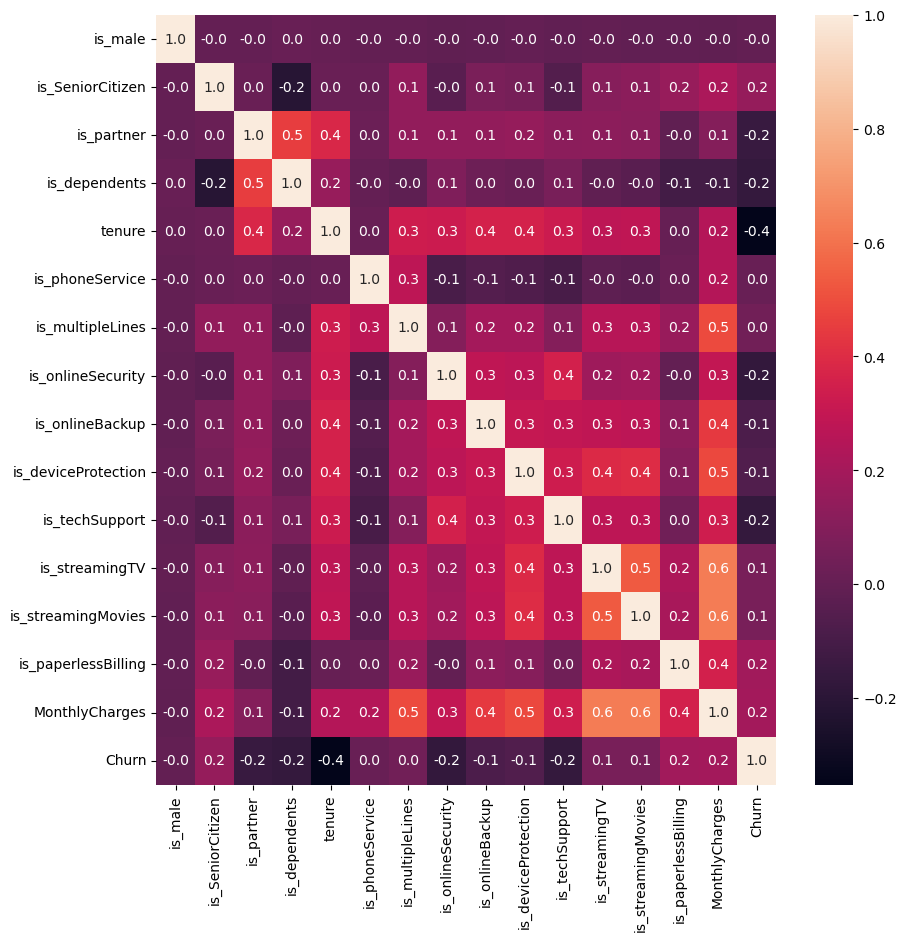

In [438]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".1f")
plt.show()

In [439]:
df.columns

Index(['customerID', 'is_male', 'is_SeniorCitizen', 'is_partner',
       'is_dependents', 'tenure', 'is_phoneService', 'is_multipleLines',
       'InternetService', 'is_onlineSecurity', 'is_onlineBackup',
       'is_deviceProtection', 'is_techSupport', 'is_streamingTV',
       'is_streamingMovies', 'Contract', 'is_paperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [440]:
df.dtypes

customerID              object
is_male                  int64
is_SeniorCitizen         int64
is_partner               int64
is_dependents            int64
tenure                   int64
is_phoneService          int64
is_multipleLines         int64
InternetService         object
is_onlineSecurity        int64
is_onlineBackup          int64
is_deviceProtection      int64
is_techSupport           int64
is_streamingTV           int64
is_streamingMovies       int64
Contract                object
is_paperlessBilling      int64
PaymentMethod           object
MonthlyCharges         float64
TotalCharges            object
Churn                    int64
dtype: object

In [441]:
df.drop("customerID",axis=1,inplace=True)

In [442]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [443]:
df=pd.get_dummies(df,columns=["InternetService"])

In [444]:
df.columns

Index(['is_male', 'is_SeniorCitizen', 'is_partner', 'is_dependents', 'tenure',
       'is_phoneService', 'is_multipleLines', 'is_onlineSecurity',
       'is_onlineBackup', 'is_deviceProtection', 'is_techSupport',
       'is_streamingTV', 'is_streamingMovies', 'Contract',
       'is_paperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'InternetService_DSL',
       'InternetService_Fiber optic', 'InternetService_No'],
      dtype='object')

In [445]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [446]:
df=pd.get_dummies(df,columns=["Contract"])

In [447]:
df.columns

Index(['is_male', 'is_SeniorCitizen', 'is_partner', 'is_dependents', 'tenure',
       'is_phoneService', 'is_multipleLines', 'is_onlineSecurity',
       'is_onlineBackup', 'is_deviceProtection', 'is_techSupport',
       'is_streamingTV', 'is_streamingMovies', 'is_paperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year'],
      dtype='object')

In [448]:
df=pd.get_dummies(df,columns=["PaymentMethod"])

In [449]:
df.columns

Index(['is_male', 'is_SeniorCitizen', 'is_partner', 'is_dependents', 'tenure',
       'is_phoneService', 'is_multipleLines', 'is_onlineSecurity',
       'is_onlineBackup', 'is_deviceProtection', 'is_techSupport',
       'is_streamingTV', 'is_streamingMovies', 'is_paperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_DSL',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [450]:
df['TotalCharges']=df['TotalCharges'].replace(' ','0')

In [451]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [452]:
X=df.drop("Churn",axis=1)
y=df['Churn']

In [453]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [454]:
X_train.shape

(5634, 26)

In [455]:
X_test.shape

(1409, 26)

In [456]:
from sklearn.tree import DecisionTreeClassifier

model1=DecisionTreeClassifier(max_depth=5,random_state=42)

model1.fit(X_train,y_train)

y_pred1=model1.predict(X_test)

print(classification_report(y_test,y_pred1))
print(accuracy_score(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1036
           1       0.62      0.65      0.64       373

    accuracy                           0.80      1409
   macro avg       0.75      0.75      0.75      1409
weighted avg       0.81      0.80      0.80      1409

0.8026969481902059


In [457]:
from sklearn.ensemble import RandomForestClassifier

model2=RandomForestClassifier(n_estimators=100,class_weight="balanced",random_state=42)

model2.fit(X_train,y_train)

y_pred2=model2.predict(X_test)

print(classification_report(y_test,y_pred2))
print(accuracy_score(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.65      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409

0.7899219304471257


In [458]:
df1=df.copy()

column=["tenure","MonthlyCharges","TotalCharges"]

se=StandardScaler()

df1[column]=se.fit_transform(df1[column])

In [459]:
X_scaled=df1.drop("Churn",axis=1)
Y=df1["Churn"]

In [460]:
X_train_S,X_test_S,Y_train,Y_test=train_test_split(X_scaled,Y,test_size=0.2,random_state=42)

In [461]:
from sklearn.linear_model import LogisticRegression

model3=LogisticRegression(max_iter=1000,class_weight="balanced")

model3.fit(X_train_S,y_train)

y_pred3=model3.predict(X_test_S)

print(classification_report(y_test,y_pred3))
print(accuracy_score(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

0.7501774308019872
